****Theoretical****

# Assignment: Support Vector Machine (SVM) and Naïve Bayes

---

## 1. What is a Support Vector Machine (SVM)?

SVM is a supervised machine learning algorithm used for classification and regression tasks.  
It finds the optimal hyperplane that separates data points of different classes with the maximum margin.

---


## 2. What is the difference between Hard Margin and Soft Margin SVM?

- **Hard Margin**: No misclassification allowed. Works only when data is linearly separable.
- **Soft Margin**: Allows some misclassification to improve generalization. Useful when data is not linearly separable.

---

## 3. What is the mathematical intuition behind SVM?

SVM aims to maximize the margin between classes by solving the following optimization problem:

$$
\
\min \frac{1}{2}||w||^2 \quad \text{subject to} \quad y_i(w \cdot x_i + b) \geq 1
\
$$
This ensures the widest possible separation between the two classes.

---

## 4. What is the role of Lagrange Multipliers in SVM?

Lagrange multipliers are used to convert the constrained optimization problem into its dual form.  
This helps in identifying support vectors and enables the use of kernel functions for non-linear decision boundaries.

---

## 5. What are Support Vectors in SVM?

Support vectors are the critical data points closest to the decision boundary.  
They define the position and orientation of the hyperplane and directly influence the model.

---

## 6. What is a Support Vector Classifier (SVC)?

SVC is an implementation of SVM for classification tasks.  
It separates classes by finding the hyperplane that maximizes the margin between them.

---

## 7. What is a Support Vector Regressor (SVR)?

SVR is the regression version of SVM.  
It attempts to fit the best function within a specified error margin (ε) from the actual outputs.

---

## 8. What is the Kernel Trick in SVM?

The kernel trick allows SVM to operate in high-dimensional feature spaces without explicitly transforming the data.  
It computes the inner product using kernel functions like polynomial or RBF, enabling non-linear classification.

---

## 9. Compare Linear Kernel, Polynomial Kernel, and RBF Kernel

| Kernel       | Use Case              | Formula                         | Remarks                         |
|--------------|-----------------------|----------------------------------|----------------------------------|
| Linear       | Linearly separable    | \( K(x, x') = x \cdot x' \)      | Fast, simple, interpretable      |
| Polynomial   | Polynomial boundaries | \( K(x, x') = (x \cdot x' + c)^d \) | Captures complex curves       |
| RBF (Gaussian)| Highly non-linear     | \( K(x, x') = e^{-\gamma ||x - x'||^2} \) | Most flexible and powerful |

---

## 10. What is the effect of the C parameter in SVM?

- **High C**: Penalizes misclassifications heavily; narrow margin.
- **Low C**: Allows some misclassifications; wider margin and better generalization.

---

## 11. What is the role of the Gamma parameter in RBF Kernel SVM?

- **High Gamma**: Model focuses more on nearby points; may overfit.
- **Low Gamma**: Points have wider influence; better generalization.

---

## 12. What is the Naïve Bayes classifier, and why is it called "Naïve"?

Naïve Bayes is a probabilistic classifier based on Bayes' Theorem.  
It is called "naïve" because it assumes all features are independent given the class, which is rarely true in practice.

---

## 13. What is Bayes’ Theorem?

Bayes’ Theorem describes the probability of an event given prior knowledge of related conditions:
$$
\[
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
\]
$$
---

## 14. Differences between Gaussian, Multinomial, and Bernoulli Naïve Bayes

| Variant     | Feature Type       | Distribution             | Use Case                     |
|-------------|--------------------|---------------------------|------------------------------|
| Gaussian    | Continuous          | Normal distribution       | Sensor data, age, income     |
| Multinomial | Count data          | Multinomial distribution  | Word counts in text          |
| Bernoulli   | Binary features     | Bernoulli distribution    | Presence/absence of features |

---

## 15. When should you use Gaussian Naïve Bayes over other variants?

Use Gaussian NB when your features are **continuous** and follow a **normal (Gaussian) distribution**.

---

## 16. What are the key assumptions made by Naïve Bayes?

- All features are conditionally independent given the class label.
- Each feature contributes equally and independently to the outcome.

---

## 17. What are the advantages and disadvantages of Naïve Bayes?

**Advantages:**
- Simple and fast
- Handles high-dimensional data well
- Effective for text classification

**Disadvantages:**
- Assumes feature independence
- May perform poorly if this assumption is violated

---

## 18. Why is Naïve Bayes a good choice for text classification?

- Text data is high-dimensional and sparse.
- Word occurrences can be treated as independent.
- It is computationally efficient and performs well.

---

## 19. Compare SVM and Naïve Bayes for classification tasks

| Aspect         | SVM                       | Naïve Bayes                 |
|----------------|---------------------------|-----------------------------|
| Speed          | Slower, especially with kernels | Very fast            |
| Accuracy       | High for complex boundaries | Decent if assumptions hold |
| Assumptions    | No assumptions on features | Assumes feature independence |
| Text data      | Accurate but slower        | Very efficient              |
| Interpretability | Moderate                 | High                        |

---

## 20. How does Laplace Smoothing help in Naïve Bayes?

Laplace Smoothing adds a small value (usually 1) to all counts to prevent zero probabilities for unseen features.  
This improves model robustness and ensures valid probability estimates.

---


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV,cross_val_score, KFold
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix

In [2]:
#21: Write a Python program to train an SVM Classifier on the Iris dataset and evaluate accuracy:
from sklearn.datasets import load_iris
X,y=load_iris(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)
from sklearn.svm import SVC
clf=SVC(kernel="linear")
clf.fit(X_train,y_train)
accuracy_score(y_test,clf.predict(X_test))

1.0

In [3]:
#22: Write a Python program to train two SVM classifiers with Linear and RBF kernels on the Wine dataset, then compare their accuracies:
from sklearn.datasets import load_wine
data= load_wine()
X=data.data
y=data.target
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)
linearModel= SVC(kernel="linear")
RBFModel=SVC(kernel="rbf")

linearModel.fit(X_train,y_train)
RBFModel.fit(X_train,y_train)

print("The accuacy of Linear Kernel :",accuracy_score(y_test,linearModel.predict(X_test)))
print("The accuacy of RBF Kernel :",accuracy_score(y_test,RBFModel.predict(X_test)))


The accuacy of Linear Kernel : 1.0
The accuacy of RBF Kernel : 0.8055555555555556


In [4]:
#23: Write a Python program to train an SVM Regressor (SVR) on a housing dataset and evaluate it using Mean Squared Error (MSE):
from sklearn.datasets import fetch_california_housing
X,y=fetch_california_housing(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)
from sklearn.svm import SVR
model =SVR()
model.fit(X_train,y_train)
print("evaluate it using Mean Squared Error (MSE): ",mean_squared_error(y_test,model.predict(X_test)))

evaluate it using Mean Squared Error (MSE):  1.332011542134874


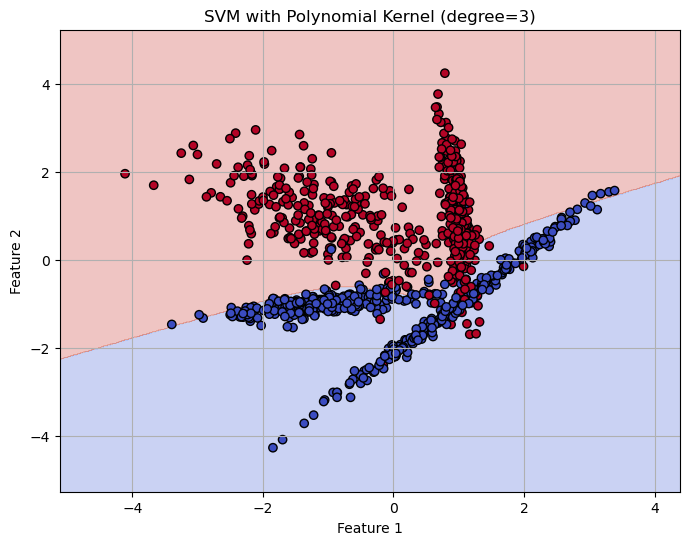

In [5]:
#24: Write a Python program to train an SVM Classifier with a Polynomial Kernel and visualize the decision boundary:
from sklearn.datasets import make_classification
X,y= make_classification(n_samples=1000,n_features=2,n_classes=2,n_redundant=0)

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)
from sklearn.svm import SVC
model =SVC(C=1,kernel="poly")
model.fit(X_train,y_train)


# Step 4: Plot decision boundary
def plot_decision_boundary(model, X, y):
    h = 0.02  # mesh step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    plt.title("SVM with Polynomial Kernel (degree=3)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

plot_decision_boundary(model, X, y)

In [6]:
#25: Write a Python program to train a Gaussian Naïve Bayes classifier on the Breast Cancer dataset and evaluate accuracy:
from sklearn.datasets import load_breast_cancer
X,y=load_breast_cancer(return_X_y=True)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)
from sklearn.naive_bayes import GaussianNB
model =GaussianNB()
model.fit(X_train,y_train)
print("The accuacy  Gaussian Naïve Bayes classifier :",accuracy_score(y_test,model.predict(X_test)))

The accuacy  Gaussian Naïve Bayes classifier : 0.9736842105263158


In [7]:
#26: Write a Python program to train a Multinomial Naïve Bayes classifier for text classification using the 20 Newsgroups dataset.
from sklearn.datasets import fetch_20newsgroups
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
data= fetch_20newsgroups()

newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

df = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target
})

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(df['text'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6514588859416446


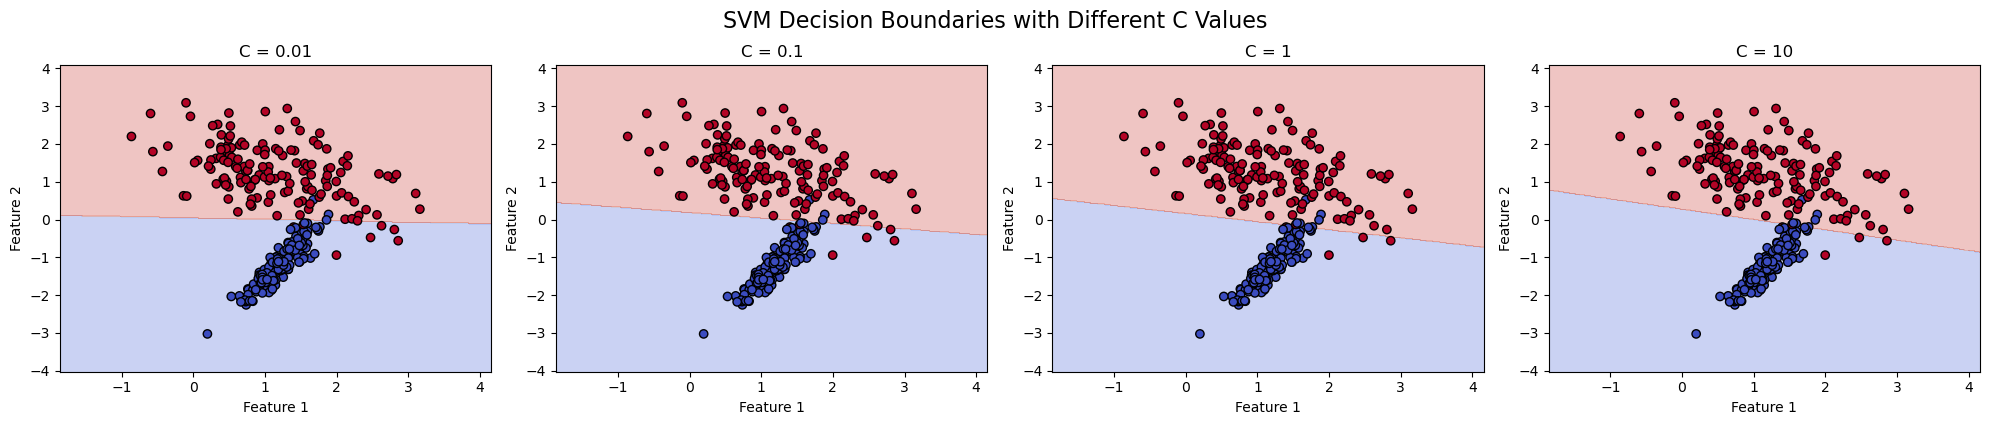

In [8]:
#27= Write a Python program to train an SVM Classifier with different C values and compare the decision boundaries visually

X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1, class_sep=1.2,
                           random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

def plot_decision_boundary(model, X, y, ax, title):
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# Try different C values
C_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(1, len(C_values), figsize=(20, 4))

for ax, C in zip(axes, C_values):
    model = SVC(C=C, kernel='linear')
    model.fit(X_train, y_train)
    plot_decision_boundary(model, X, y, ax, f"C = {C}")

plt.tight_layout()
plt.suptitle("SVM Decision Boundaries with Different C Values", fontsize=16, y=1.05)
plt.show()



In [9]:
#28= Write a Python program to train a Bernoulli Naïve Bayes classifier for binary classification on a dataset with binary features=
from sklearn.naive_bayes import BernoulliNB
model = BernoulliNB()

X, y = make_classification(n_samples=1000, n_features=20, n_informative=5,
                           n_redundant=0, n_classes=2, random_state=42)
X_binary =(X>0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X_binary, y, test_size=0.2, random_state=42)

model = BernoulliNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.755
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.78       107
           1       0.75      0.71      0.73        93

    accuracy                           0.76       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.76      0.75       200



Accuracy to apply feature scaling before training  0.9824561403508771
Accuracy to without feature scaling  0.9824561403508771


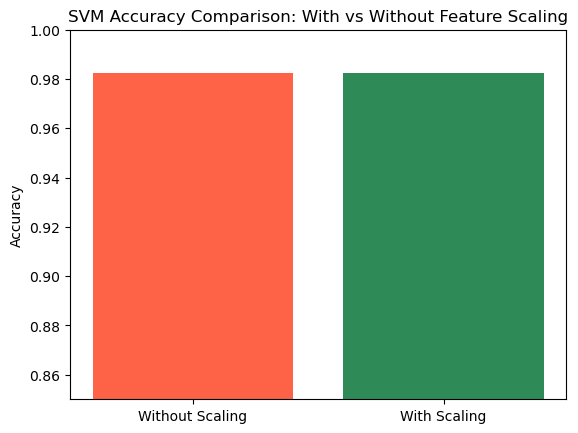

In [10]:
#29= Write a Python program to apply feature scaling before training an SVM model and compare results with unscaled data
from sklearn.preprocessing import StandardScaler
scale =StandardScaler()

from sklearn.datasets import load_breast_cancer
X,y =load_breast_cancer(return_X_y=True)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train_scale =scale.fit_transform(X_train)
X_test_scale= scale.transform(X_test)

model1_scale = SVC()
model1_scale.fit(X_train_scale,y_train)
y_pred_scale=model1_scale.predict(X_test_scale)

acc1=accuracy_score(y_test,y_pred_scale)

model2=SVC()
model2.fit(X_train_scale,y_train)
y_pred=model2.predict(X_test_scale)

acc2=accuracy_score(y_test,y_pred)
print("Accuracy to apply feature scaling before training " ,acc1)
print("Accuracy to without feature scaling " ,acc2)

accuracies=[acc2,acc1]
labels=['Without Scaling', 'With Scaling']
plt.bar(labels, accuracies, color=['tomato', 'seagreen'])
plt.ylim(0.85, 1.0)
plt.title('SVM Accuracy Comparison: With vs Without Feature Scaling')
plt.ylabel('Accuracy')
plt.show()



In [11]:
#30= Write a Python program to train a Gaussian Naïve Bayes model and compare the predictions before and after Laplace Smoothing
X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("GaussianNB Accuracy (no Laplace smoothing):", acc)

#there is no method for non-laplace smoothing in Gaussian Naive

GaussianNB Accuracy (no Laplace smoothing): 1.0


In [12]:
#31= Write a Python program to train an SVM Classifier and use GridSearchCV to tune the hyperparameters (C, gamma, kernel)=
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
param = {
    "C": [0.1, 0.5, 1],
    "gamma": [0.5, 1, 5],
    "kernel": ['linear', 'poly', 'rbf', 'sigmoid']
}
from sklearn.datasets import load_iris
X,y=load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

# GridSearchCV
model = GridSearchCV(estimator=SVC(), param_grid=param, cv=5, scoring="accuracy", verbose=1)
model.fit(X_train, y_train)

print("Best Score: ", model.best_score_)
print("Best Parameters: ", model.best_params_)
print("Test Accuracy: ", model.score(X_test, y_test))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Score:  0.9666666666666666
Best Parameters:  {'C': 0.5, 'gamma': 5, 'kernel': 'rbf'}
Test Accuracy:  1.0


Default SVM Accuracy: 0.97
Weighted SVM Accuracy: 0.935


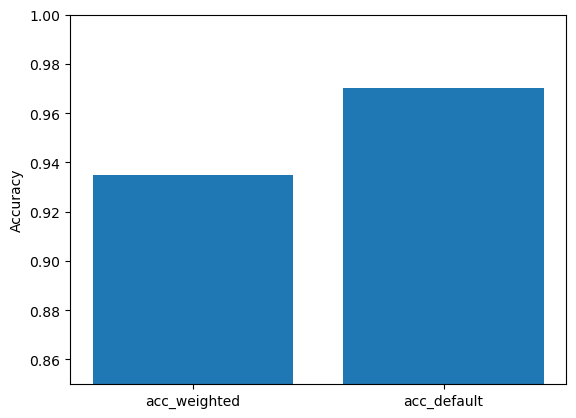

In [13]:
#32= Write a Python program to train an SVM Classifier on an imbalanced dataset and apply class weighting and check it improve accuracy
from sklearn.datasets import make_classification
from sklearn.svm import SVC,SVR
X,y = make_classification(n_classes=2,n_redundant=0,n_samples=1000,n_features=3,weights=[.9,.1])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model1=SVC()
model2 =SVC(class_weight="balanced")

model1.fit(X_train,y_train)
acc_default=accuracy_score(y_test, model1.predict(X_test))

model2.fit(X_train,y_train)
acc_weighted=accuracy_score(y_test, model2.predict(X_test))

print("Default SVM Accuracy:", acc_default)
print("Weighted SVM Accuracy:", acc_weighted)

labels =["acc_weighted","acc_default"]
acc=[acc_weighted,acc_default]
plt.bar(labels,acc)
plt.ylim(0.85,1)
plt.ylabel('Accuracy')
plt.show()

In [14]:
#33= Write a Python program to implement a Naïve Bayes classifier for spam detection using email data=
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Sample data
emails = [
    "Win a brand new iPhone now!!!",                        # spam
    "Get cheap loans at 0% interest. Click here!",          # spam
    "Important: Update your bank account details now",      # spam
    "Congratulations, you've won a lottery!",               # spam
    "Urgent: Pay your electricity bill immediately",        # spam
    "Free coupon inside, claim your prize today",           # spam
    "You have been selected for a free vacation",           # spam
    "Limited-time offer, act now!",                         # spam
    "Buy 1 get 1 free on all products",                     # spam
    "Your Amazon order has been shipped",                   # ham
    "Meeting scheduled for tomorrow at 10 AM",              # ham
    "Let's catch up over coffee next week",                 # ham
    "Can you send me the assignment by today?",             # ham
    "Don't forget to bring your ID card",                   # ham
    "Reminder: Your doctor's appointment is at 3 PM",       # ham
    "Thanks for your help on the project",                  # ham
    "Lunch at my place tomorrow?",                          # ham
    "Team outing has been postponed to Friday",             # ham
    "Here's the link to the notes from class",              # ham
    "See you at the wedding next month!"                    # ham
]

labels = [
    1, 1, 1, 1, 1, 1, 1, 1, 1, 
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0 
]
# Convert text to numerical features
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(emails)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.3, random_state=42)
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred,zero_division=0))


              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



In [15]:
#34= Write a Python program to train an SVM Classifier and a Naïve Bayes Classifier on the same dataset and compare their accuracy=
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model1=SVC()
model2=GaussianNB()

model1.fit(X_train,y_train)
acc1=accuracy_score(y_test, model1.predict(X_test))

model2.fit(X_train,y_train)
acc2=accuracy_score(y_test, model2.predict(X_test))

print("a Naïve Bayes Classifier Accuracy :", acc1)
print("an SVM Classifier Accuracy:", acc2)


a Naïve Bayes Classifier Accuracy : 0.9473684210526315
an SVM Classifier Accuracy: 0.9736842105263158


In [16]:
#35= Write a Python program to perform feature selection before training a Naïve Bayes classifier and compare results
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
rfe =RFE(estimator=DecisionTreeClassifier(),n_features_to_select=12) #total feature =30

from sklearn.datasets import load_breast_cancer
data= load_breast_cancer()
y=data.target
X=data.data

#result without feature selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model= GaussianNB()
model.fit(X_train,y_train)
acc1=accuracy_score(y_test, model.predict(X_test))
print("a Naïve Bayes Classifier Accuracy  without feature selection :", acc1)

#perform feature selection before training a Naïve Bayes classifier 

df=pd.DataFrame(data.data, columns=data.feature_names)
rfe.fit(X,y)
X=df.loc[:,rfe.support_]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model2= GaussianNB()
model2.fit(X_train,y_train)
acc2=accuracy_score(y_test, model2.predict(X_test))
print("a Naïve Bayes Classifier Accuracy perform feature selection before training :", acc2)

print("Selected features:")
print(df.columns[rfe.support_].tolist())


a Naïve Bayes Classifier Accuracy  without feature selection : 0.9736842105263158
a Naïve Bayes Classifier Accuracy perform feature selection before training : 0.9649122807017544
Selected features:
['mean concave points', 'perimeter error', 'area error', 'smoothness error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points']


In [17]:
#36= Write a Python program to train an SVM Classifier using One-vs-Rest (OvR) and One-vs-One (OvO) strategies on the Wine dataset and compare their accuracy=
from sklearn.datasets import load_wine
X,y =load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model =SVC(decision_function_shape='ovr',C=1)
model.fit(X_train,y_train)
acc1=accuracy_score(y_test, model.predict(X_test))
print("An SVM Classifier using One-vs-Rest (OvR) Accuracy :", acc1)

model2 =SVC(decision_function_shape='ovo',C=1)
model2.fit(X_train,y_train)
acc2=accuracy_score(y_test, model2.predict(X_test))
print("An SVM Classifier using One-vs-One (OvO) Accuracy :", acc2)



An SVM Classifier using One-vs-Rest (OvR) Accuracy : 0.8055555555555556
An SVM Classifier using One-vs-One (OvO) Accuracy : 0.8055555555555556


 an SVM Classifier using Linear kernels Accuracy : 0.9473684210526315
 an SVM Classifier using Linear kernels Accuracy : 0.956140350877193
 an SVM Classifier using RBF kernels) Accuracy : 0.9473684210526315


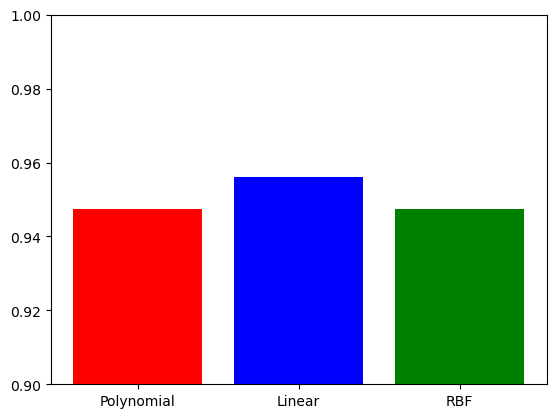

In [18]:
#37= Write a Python program to train an SVM Classifier using Linear, Polynomial, and RBF kernels on the Breast Cancer dataset and compare their accuracy=
from sklearn.datasets import load_breast_cancer
X,y =load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model =SVC(kernel="poly",degree=3,C=1)
model.fit(X_train,y_train)
acc1=accuracy_score(y_test, model.predict(X_test))
print(" an SVM Classifier using Linear kernels Accuracy :", acc1)

model2 =SVC(kernel="linear",C=1)
model2.fit(X_train,y_train)
acc2=accuracy_score(y_test, model2.predict(X_test))
print(" an SVM Classifier using Linear kernels Accuracy :", acc2)

model3 =SVC(kernel="rbf",C=1)
model3.fit(X_train,y_train)
acc3=accuracy_score(y_test, model3.predict(X_test))
print(" an SVM Classifier using RBF kernels) Accuracy :", acc3)

acc=[acc1,acc2,acc3]
plt.bar(x=['Polynomial','Linear', 'RBF'],height=acc,color=["r","b","g"])
plt.ylim(0.9,1)
plt.show()

In [19]:
#38= Write a Python program to train an SVM Classifier using Stratified K-Fold Cross-Validation and compute the average accuracy
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.datasets import load_breast_cancer
X,y =load_breast_cancer(return_X_y=True)

fold=StratifiedKFold(n_splits=5,shuffle=True)
scores=cross_val_score(estimator=SVC(),X=X,scoring="accuracy",y=y,cv=fold)
print("average score ",scores.mean())

average score  0.9138953578636857


Accuracy with default priors: 0.9736842105263158
Accuracy with equal priors [0.5, 0.5]: 0.9736842105263158
Accuracy with priors [0.7, 0.3]: 0.9649122807017544


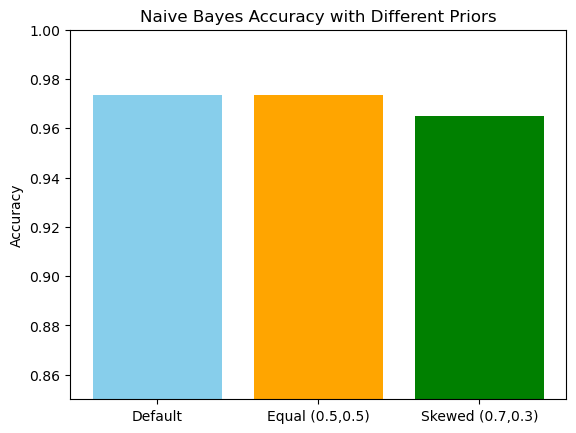

In [20]:
#39= Write a Python program to train a Naïve Bayes classifier using different prior probabilities and compare performance
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 1. Train with default priors
model_default = GaussianNB()
model_default.fit(X_train, y_train)
pred_default = model_default.predict(X_test)
acc_default = accuracy_score(y_test, pred_default)
print("Accuracy with default priors:", acc_default)

# 2. Train with custom priors (equal)
model_equal = GaussianNB(priors=[0.5, 0.5])
model_equal.fit(X_train, y_train)
pred_equal = model_equal.predict(X_test)
acc_equal = accuracy_score(y_test, pred_equal)
print("Accuracy with equal priors [0.5, 0.5]:", acc_equal)

# 3. Train with custom priors (skewed)
model_skewed = GaussianNB(priors=[0.7, 0.3])
model_skewed.fit(X_train, y_train)
pred_skewed = model_skewed.predict(X_test)
acc_skewed = accuracy_score(y_test, pred_skewed)
print("Accuracy with priors [0.7, 0.3]:", acc_skewed)

# Compare in bar chart
labels = ['Default', 'Equal (0.5,0.5)', 'Skewed (0.7,0.3)']
accuracies = [acc_default, acc_equal, acc_skewed]

plt.bar(labels, accuracies, color=['skyblue', 'orange', 'green'])
plt.ylim(0.85, 1.0)
plt.ylabel("Accuracy")
plt.title("Naive Bayes Accuracy with Different Priors")
plt.show()

In [21]:
#40= Write a Python program to perform Recursive Feature Elimination (RFE) before training an SVM Classifier and compare accuracy
rfe =RFE(estimator=SVC(kernel='linear'),n_features_to_select=20)
data=load_breast_cancer()
X,y = load_breast_cancer(return_X_y=True)
rfe.fit(X,y)
rfe.support_

#without RFE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.pipeline import Pipeline
pline = Pipeline([
    ("scaling",StandardScaler()),
    ("model",SVC())
    ])
pline.fit(X_train,y_train)
print("Accuracy without the RFE -> ",accuracy_score(y_test,pline.predict(X_test)))
#with RFE
df= pd.DataFrame(X)
X =df.loc[:,rfe.support_]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pline.fit(X_train,y_train)

print("Accuracy with the RFE -> ",accuracy_score(y_test,pline.predict(X_test)))

Accuracy without the RFE ->  0.9824561403508771
Accuracy with the RFE ->  0.9649122807017544


In [22]:
#41= Write a Python program to train an SVM Classifier and evaluate its performance using Precision, Recall, and F1-Score instead of accuracy=
from sklearn.metrics import classification_report,recall_score,precision_score,f1_score,log_loss
data=load_breast_cancer()
X,y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.pipeline import Pipeline
pline = Pipeline([
    ("scaling",StandardScaler()),
    ("model",SVC())
    ])
pline.fit(X_train,y_train)
y_pred =pline.predict(X_test)

print("classification_report",classification_report(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("F1-Score",f1_score(y_test,y_pred))


classification_report               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Precision 0.9726027397260274
Recall 1.0
F1-Score 0.9861111111111112


In [23]:
#42= Write a Python program to train a Naïve Bayes Classifier and evaluate its performance using Log Loss (Cross-Entropy Loss)=

from sklearn.metrics import log_loss
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  # Required for log loss
acc = accuracy_score(y_test, y_pred)
print("Accuracy with default priors:", acc)

print("performance using Log Loss (Cross-Entropy Loss)= ",log_loss(y_test,y_prob) )

Accuracy with default priors: 0.9736842105263158
performance using Log Loss (Cross-Entropy Loss)=  0.20373427152141899


classification_report [[41  2]
 [ 0 71]]


<Axes: >

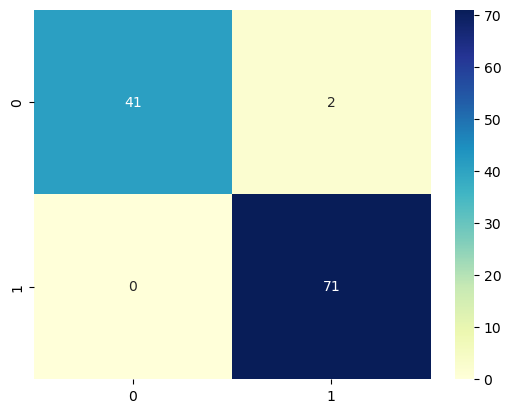

In [24]:
#43= Write a Python program to train an SVM Classifier and visualize the Confusion Matrix using seaborn=
data=load_breast_cancer()
X,y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.pipeline import Pipeline
pline = Pipeline([
    ("scaling",StandardScaler()),
    ("model",SVC())
    ])
pline.fit(X_train,y_train)
y_pred =pline.predict(X_test)

print("classification_report",confusion_matrix(y_test,y_pred))
sns.heatmap(data=confusion_matrix(y_test,y_pred),annot=True, cmap="YlGnBu")


In [25]:
#44= Write a Python program to train an SVM Regressor (SVR) and evaluate its performance using Mean Absolute Error (MAE) instead of MSE=
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=1000,n_features=5, noise=10,)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model =Pipeline([
    ("scaling",StandardScaler()),
    ("SVR",SVR())
])
model.fit(X_train,y_train)
print(" performance using Mean Absolute Error (MAE): ",mean_absolute_error(y_test,model.predict(X_test)))

 performance using Mean Absolute Error (MAE):  42.51573200704473


In [26]:
#45= Write a Python program to train a Naïve Bayes classifier and evaluate its performance using the ROC-AUC score
from sklearn.metrics import roc_auc_score 
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  
score = roc_auc_score(y_test, y_prob[:,1])
print("Accuracy with default priors:", score)


Accuracy with default priors: 0.9983622666229938


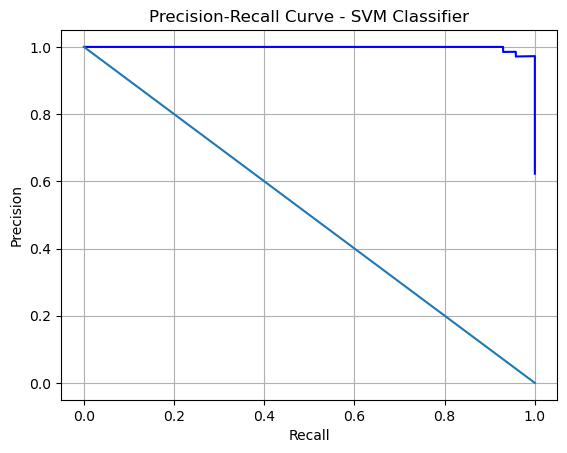

In [27]:
#46 Write a Python program to train an SVM Classifier and visualize the Precision-Recall Curve.
from sklearn.metrics import precision_recall_curve,auc
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model =Pipeline([
    ("scaling",StandardScaler()),
    ("SVR",SVC(probability=True))
])
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)  
precision, recall, thresholds =precision_recall_curve(y_test,y_prob[:,1])
#score= auc(precision,recall)

plt.plot(recall, precision,color='blue')
plt.plot([1,0],[0,1])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - SVM Classifier')

plt.grid(True)
plt.show()